#### Assuntos
1. EDA Completa
Analisamos o dataset antes de modelar, compreendendo status, distribuições e padrões temporais.

2. Gráficos Essenciais
Barras, histogramas, scatter plot e boxplot - cada um responde a um tipo de pergunta

3. Correlação != Causalidade
Heatmaps e scatter plots mostram associações, masn não implicam causa e efeito

In [ ]:
# matplotlib style
plt.style.use("ggplot")

# Not show more number of columns
pd.set_option("display.max_columns", None)

In [ ]:
# To read the dataset
df = pd.read_csv("dataset/ncr_ride_bookings.csv", na_values=["null"])

In [ ]:
# Some cleaning up, more on Aula 3.

# Guarentee that numeric columns are really showed as numbers
df["Booking Value"] = pd.to_numeric(df["Booking Value"], errors="coerce")

# To clean up specific columns
df["Booking ID"] = df["Booking ID"].str.replace('"', "", regex=False)
df["Customer ID"] = df["Customer ID"].str.replace('"', "", regex=False)

# To have a better date.
df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")

# To show only the completed runs.
df_ok = df[df["Booking Status"] == "Completed"].copy()

In [145]:
print(
    f"Dados prontos: {len(df):,} corridas \nCorridas no total: {len(df_ok):,} completadas"
)
print(df.head())
print(df.describe())

Dados prontos: 150,000 corridas 
Corridas no total: 93,000 completadas
        Date                Time  Booking ID   Booking Status Customer ID  \
0 2024-03-23 1900-01-01 12:29:38  CNR5884300  No Driver Found  CID1982111   
1 2024-11-29 1900-01-01 18:01:39  CNR1326809       Incomplete  CID4604802   
2 2024-08-23 1900-01-01 08:56:10  CNR8494506        Completed  CID9202816   
3 2024-10-21 1900-01-01 17:17:25  CNR8906825        Completed  CID2610914   
4 2024-09-16 1900-01-01 22:08:00  CNR1950162        Completed  CID9933542   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3

C:\Users\josia\AppData\Local\Temp\ipykernel_11348\2263038975.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_by_vehicle.values, y=mean_by_vehicle.index, palette="viridis")


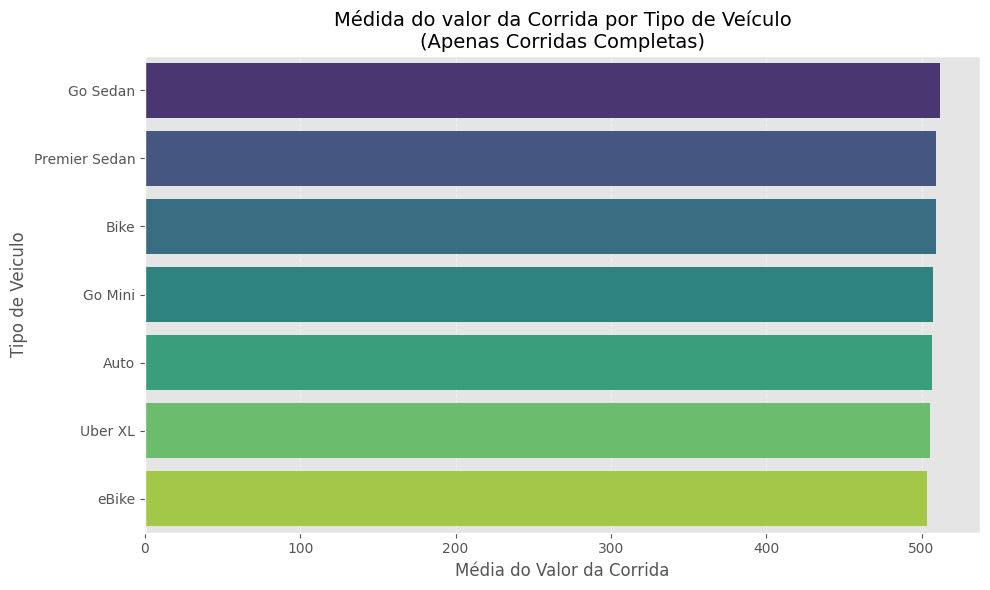

In [154]:
# Grafico feito por IA (da aula)

df_completed = df[df["Booking Status"] == "Completed"]

mean_by_vehicle = (
    df_completed.groupby("Vehicle Type")["Booking Value"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(x=mean_by_vehicle.values, y=mean_by_vehicle.index, palette="viridis")

plt.title(
    "Médida do valor da Corrida por Tipo de Veículo\n(Apenas Corridas Completas)",
    fontsize=14,
)
plt.xlabel("Média do Valor da Corrida")
plt.ylabel("Tipo de Veiculo")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# Graifco 1 - O que aconteceu com cada corrida?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(
    status.values,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set1", len(status)),
)
axes[0].set_title("proporção por status")

status.plot(kind="barh", ax=axes[1], color=sns.color_palette("Set2", len(status)))
axes[1].set_title("Quantidade por Status")
axes[1].set_xlabel("Número de Corridas")

plt.tight_layout()
plt.show()

In [ ]:
# Grafico 2 - Qual tipo de veículo é mais usado?

veic_qtd = df["Vehicle Type"].value_counts()
veic_valor = (
    df_ok.groupby("Vehicle Type")["Booking Value"].mean().sort_values(ascending=False)
)

print("\n Média do valor da corrida por tipo de veiculo (apenas completadas)")
print(veic_valor.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

veic_qtd.sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("corridas por Tipo de Veículo")
axes[0].set_xlabel("Quantidade")

veic_valor.sort_values().plot(
    kind="barh", ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("Valor Médio da Corrida por Veículo (R$)")
axes[1].set_xlabel("Valor Médio")


plt.tight_layout()
plt.show()

In [ ]:
# Grafico 3 - Em que hora do dia correm mais corridas

corridas_hora = df.groupby(df["Time"].dt.hour).size()
valor_hora = (
    df_ok.assign(hora=df_ok["Time"].dt.hour).groupby("hora")["Booking Value"].mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    corridas_hora.index, corridas_hora.values, color="steelblue", edgecolor="white"
)

axes[0].axvspan(7, 10, alpha=0.2, color="red", label="Pico manhã (7-10h)")
axes[0].axvspan(17, 20, alpha=0.2, color="blue", label="Pico tarde (17-20h)")
axes[0].set_title("Corridas por Hora do Dia")
axes[0].set_xlabel("Hora (0-23)")
axes[0].set_ylabel("Nº de Corridas")
axes[0].set_xticks(range(0, 24))
axes[0].legend()

axes[1].plot(
    valor_hora.index,
    valor_hora.values,
    color="darkorange",
    linewidth=2,
    marker="o",
    markersize=4,
)
axes[1].axvspan(7, 10, alpha=0.2, color="red")
axes[1].axvspan(17, 20, alpha=0.2, color="blue")
axes[1].set_title("Valor Médio da Corrida por Hora (R$)")
axes[1].set_xlabel("Hora (0-23)")

plt.suptitle("Padrão Temporal das Corridas", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Grafico 4 - Como é a distribuição do valor das corridas?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    df_ok["Booking Value"].dropna(), bins=50, color="steelblue", edgecolor="white"
)
axes[0].set_title("distribuição do Valor (dados completos)")
axes[0].set_xlabel("R$")
axes[0].set_ylabel("Frequência")

axes[1].boxplot(
    df_ok["Booking Value"].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    flierprops=dict(marker="o", markersize=3, markerfacecolor="red", alpha=0.5),
)
axes[1].set_title("Boxplot - Onde estão os outliers?")
axes[1].set_ylabel("R$")

plt.suptitle("Distribuição do Valor das Corridas", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Grafico 5 - Distancia e valor se relacionam?

amostra = df_ok.dropna(subset=["Ride Distance", "Booking Value"]).sample(
    n=3000, random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(
    amostra["Ride Distance"],
    amostra["Booking Value"],
    alpha=0.3,
    s=8,
    color="steelblue",
)
plt.xlabel("Distance da Corrida (km)")
plt.ylabel("Valor da Corrida (R$)")
plt.title("Distancia vs Valor da Corrida\n(3.000 corridas aleatorias)")
plt.tight_layout()
plt.show()

corr = df_ok["Ride Distance"].corr(df_ok["Booking Value"])
print(f"Correlação entre distancia e valor: {corr:.3f}")
print()
print("Correlação vai de -1 a +1:")
print(" +1.0 = relação pereita positiva")

In [ ]:
# Grafico 6 - Correlação entre todas as variaveis numéricas

colunas = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating",
]

corr_matrix = df_ok[colunas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 11},
)
plt.title("Correlação ent re as Variaveis Numéricas\n (corridas comletas)")
plt.tight_layout()
plt.show()